In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

1. Оглянемо датасет для ознайомлення із структурою

In [9]:
df = pd.read_csv('../data/train.csv')

In [10]:
print(f'Dataset shape: {df.shape}')

df.head()

Dataset shape: (10003, 3)


,text,label,label_text
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        10003 non-null  str  
 1   label       10003 non-null  int64
 2   label_text  10003 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1022.0 KB


У датасеті маємо 3 колонки:
- text: текст запиту клієнта
- label: числове позначення категорії запиту (цільова колонка)
- label_text: назва категорії запиту

2. Перевіримо чи є пропущені значення

In [13]:
missing = df.isnull().sum()
missing

text          0
label         0
label_text    0
dtype: int64

У датасеті відсутні пропущені значення

3. Перевіримо чи є дублікати

In [15]:
duplicates = df.duplicated().sum()

print(f'Duplicate rows counter: {duplicates}')

Duplicate rows counter: 0


In [16]:
text_duplicates = df['text'].duplicated().sum()

print(f'Duplicate texts: {text_duplicates}')

Duplicate texts: 0


Дублікати відсутні

5. Проаналізуємо цільову змінну

Побудуємо графік розподілу класів цільової колонки

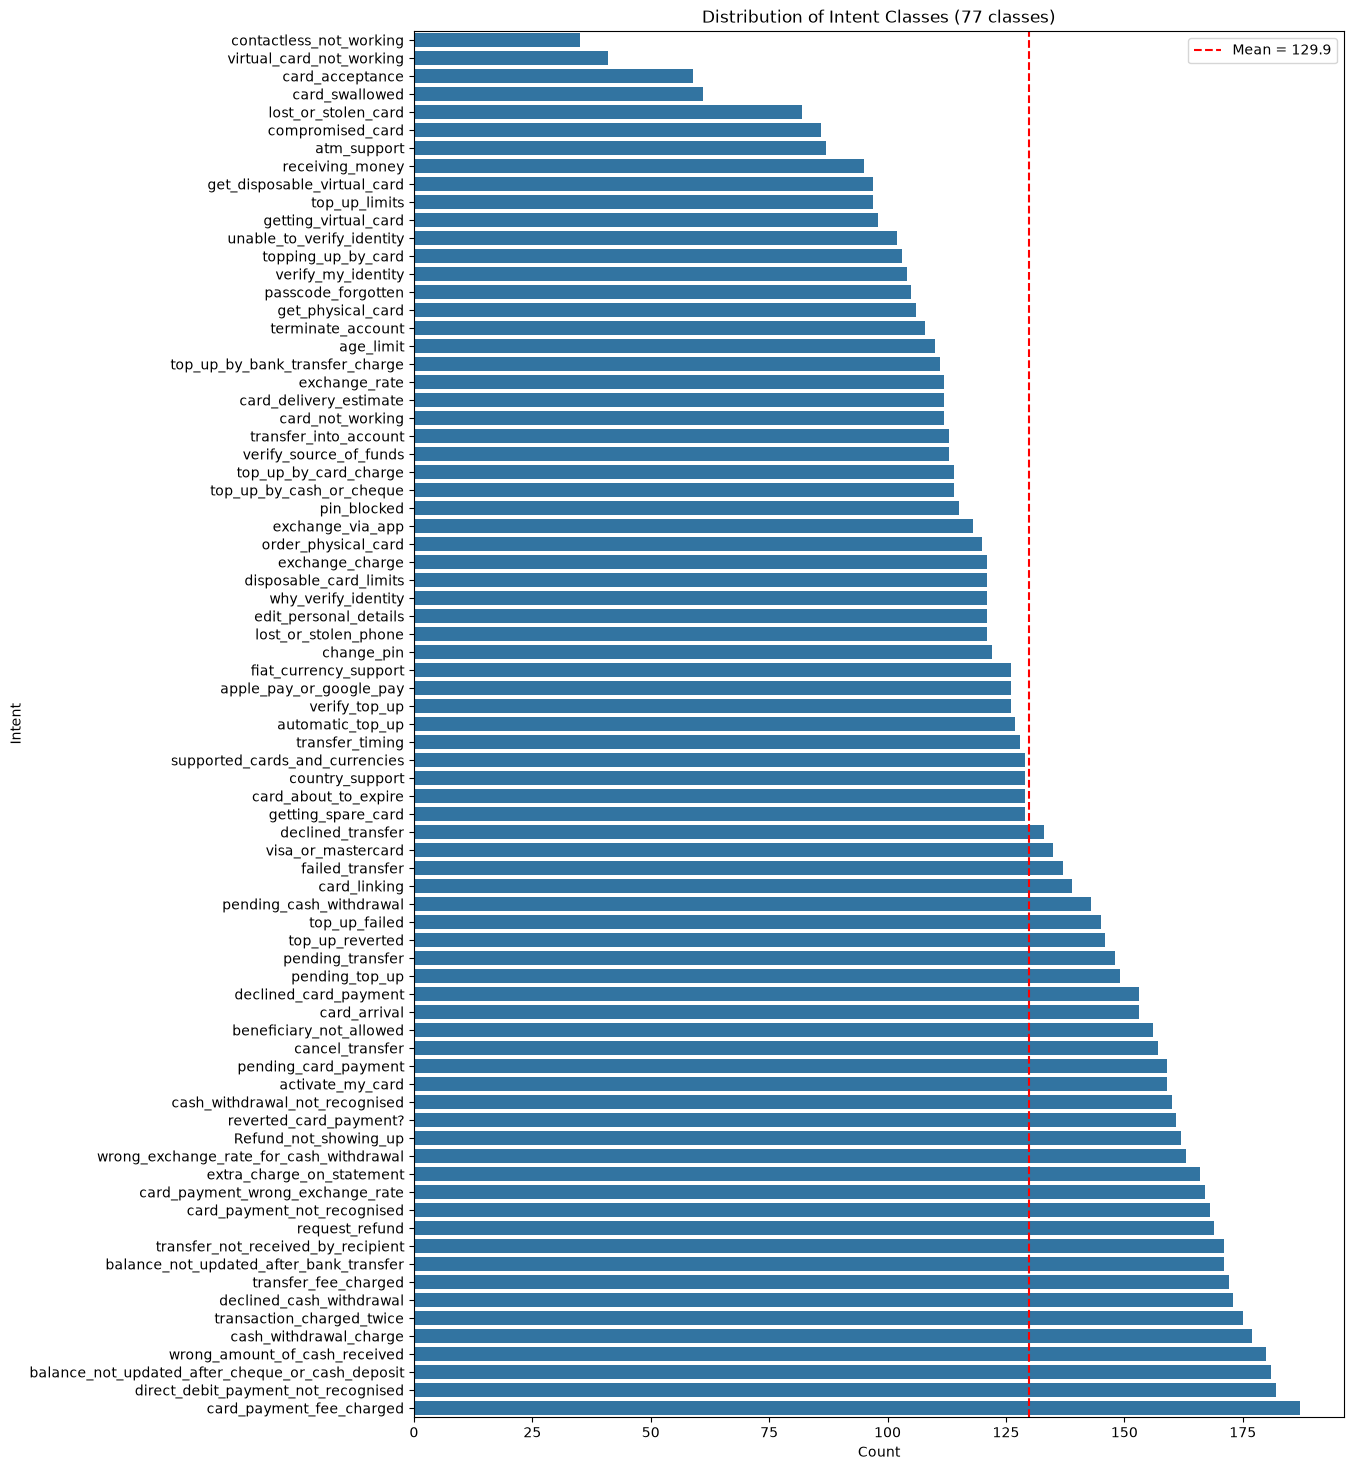

In [21]:
intent_counts = (
    df['label_text']
    .value_counts()
    .sort_values()
)

mean_count = intent_counts.mean()

plt.figure(figsize=(12, 18))

sns.barplot(
    x=intent_counts.values,
    y=intent_counts.index
)

plt.title('Number of samples per intent')
plt.xlabel('Count')
plt.ylabel('Intent')

plt.axvline(
    mean_count,
    color='red',
    linestyle='--',
    label=f'Mean = {mean_count:.1f}'
)
plt.title(
    f'Distribution of Intent Classes ({len(intent_counts)} classes)'
)
plt.legend()

plt.show()

5.2 Проаналізуємо довжину тексту. Для цього спочатку додамо колонку із значенням довжини тексту, а потім побудуємо графік.

In [22]:
df['char_count'] = df['text'].str.len()

df['word_count'] = (
    df['text']
    .str.split()
    .str.len()
)

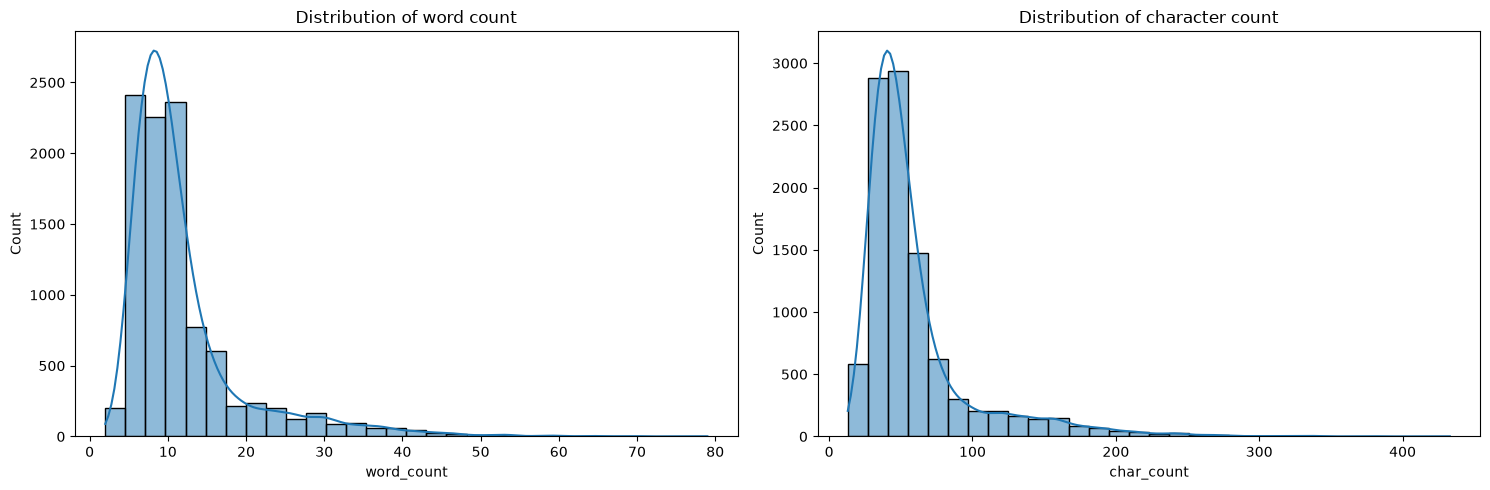

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))

sns.histplot(
    df['word_count'],
    bins=30,
    kde=True,
    ax=ax[0]
)

ax[0].set_title('Distribution of word count')

sns.histplot(
    df['char_count'],
    bins=30,
    kde=True,
    ax=ax[1]
)

ax[1].set_title('Distribution of character count')

plt.tight_layout()
plt.show()

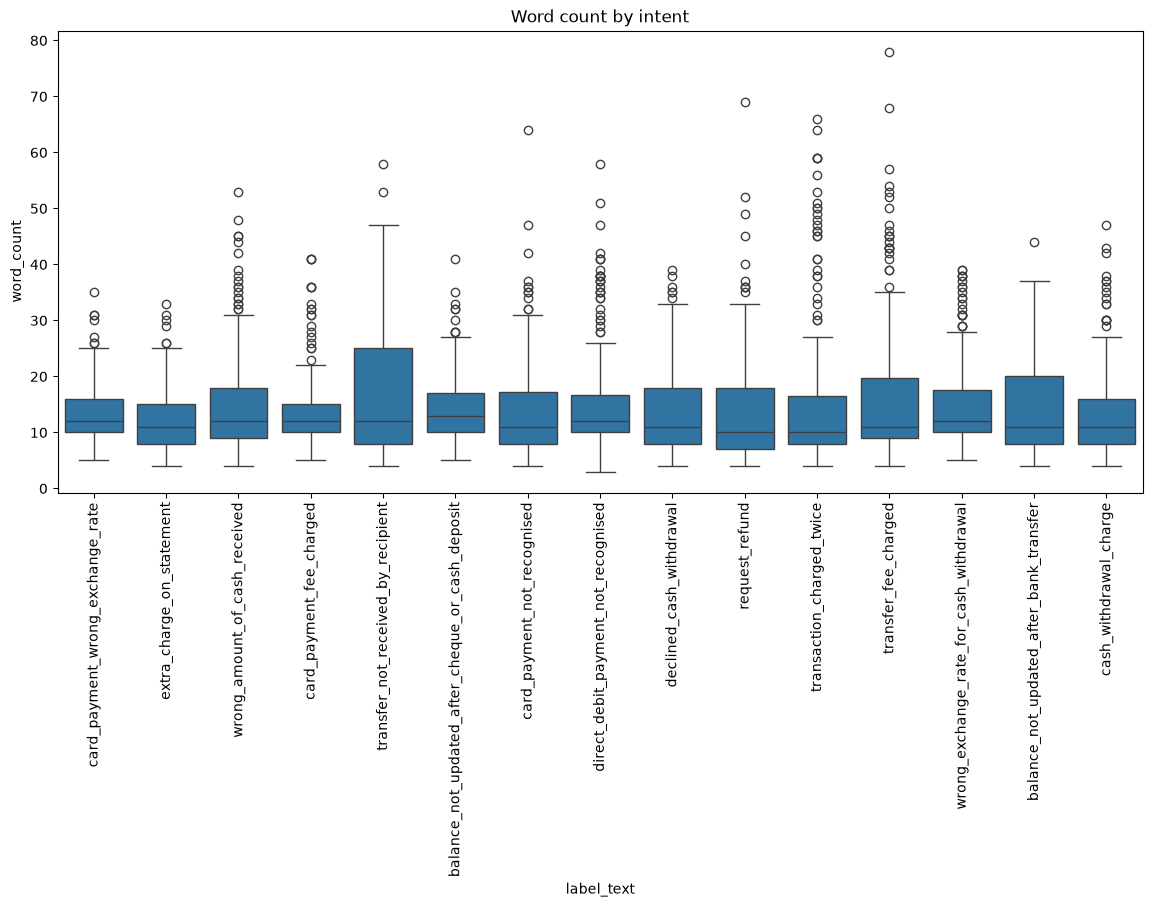

In [25]:
top_intents = (
    df['label_text']
    .value_counts()
    .head(15)
    .index
)

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df[
        df['label_text'].isin(top_intents)
    ],
    x='label_text',
    y='word_count'
)

plt.xticks(rotation=90)

plt.title('Word count by intent')

plt.show()

In [26]:
df[
    ['word_count', 'char_count']
].describe()

,word_count,char_count
count,10003.000000,10003.000000
mean,11.949415,59.473758
std,7.891577,40.867901
min,2.000000,13.000000
25%,7.000000,36.000000
50%,10.000000,47.000000
75%,13.000000,64.000000
max,79.000000,433.000000


Висновки
- з графіків бачимо правосторонню асиметрію. Більшість повідомлень короткі, але є невелика кількість дуже довгих повідомлень.
- повідомлення короткі, у середньому 12 слів, 60 символів. Модель має зрозуміти намір буквально по одному реченню.
- медіана менша за середнє (10 < 12), що підтверджує правосторонню асиметрію.
- половина повідомлень має 7-13 слів, дуже вузький діапазон.
- викидів дуже мало (макс 79 слів та 433 символи) і вони рівномірно розприділені по категоріях (приблизно по 40-70 слів).
- медіана майже однакова для всіх класів, тобто довжина повідомлення майже не залежить від типу звернення.
- є декілька класів з більшою варіативністю (transfer_not_received_by_recipient, balance_not_updated_after_bank_transfer, transfer_fee_charged). Це класи повязані із переказами, логічно що клієнту потрібно детальніше описати проблему у таких зверненнях.

6. Проаналізуємо словник звернень

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

def frequency_distribution(vectorizer: CountVectorizer, df: pd.DataFrame):
    X = vectorizer.fit_transform(df)
    word_counts = X.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    freq = (
        pd.DataFrame({
            'word': words,
            'count': word_counts
        })
        .sort_values('count', ascending=False)
    )

    return freq

In [33]:
vectorizer = CountVectorizer(stop_words='english')

df_train = df['text']
freq = frequency_distribution(vectorizer, df_train)

freq.head(20)

,word,count
275,card,2682
39,account,1352
1141,money,1133
1872,transfer,1084
1262,payment,751
1164,need,698
282,cash,691
638,exchange,549
302,charged,529
162,atm,482


Бачимо що топ використовуваних слів належать до банківського домену

In [35]:
vectorizer_bi = CountVectorizer(
    stop_words='english',
    ngram_range=(2,2)
)

df_train_bi = df['text']
freq_bi = frequency_distribution(vectorizer_bi, df_train_bi)
freq_bi.head(20)

,word,count
4830,exchange rate,293
8789,new card,226
2096,card payment,202
14346,virtual card,181
2413,cash withdrawal,165
8217,money account,148
13378,transfer money,118
7671,long does,109
4260,direct debit,102
5019,extra fee,97


Дуже хороший результат, деякі біграми майже описують категорію звернення

In [37]:
for category in df['label_text'].unique():
    vectorizer = CountVectorizer(stop_words='english')
    df_category = df[df['label_text'] == category]
    df_category_text = df_category['text']
    freq_category = frequency_distribution(vectorizer, df_category_text)
    print(f'Category: {category}')
    print(freq_category.head(10))
    print('---')

Category: card_arrival
        word  count
9       card    149
51       new     50
82     track     29
70      sent     28
33      hasn     17
34     haven     14
84  tracking     13
91      week     13
63  received     12
18  delivery     12
---
Category: card_linking
          word  count
10        card    145
6          app     56
38        link     44
51         new     35
44        lost     29
65  reactivate     24
5          add     14
85        want     13
80     thought     13
49     morning     11
---
Category: exchange_rate
          word  count
31    exchange    104
62        rate     53
63       rates     50
46        know     16
38     foreign     10
10  calculated      7
26        does      6
47        like      6
18     current      5
70        tell      5
---
Category: card_payment_wrong_exchange_rate
          word  count
54    exchange    159
115       rate    159
159      wrong     68
16      bought     34
23     charged     32
102    payment     31
83        item   

З даного аналізу бачимо що більшість категорій містить особливий словниковий набір, хоча можемо бачити що багато з катеогорій також містять спільну фінансову термінологію (пін код, активація, бенефіціар і т.д.). Це свідчить про те що традиційні піходи на основі bag-of-words повинні добре працювати на багатьох класах, тоді як тоді як моделі на основі трансформаторів можуть забезпечити додаткові покращення при розрізненні семантично подібних намірів.

In [41]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)

X = vectorizer.fit_transform(df['text'])

intent_names = sorted(df['label_text'].unique())
intent_vectors = []

for intent in intent_names:
    mask = (df['label_text'] == intent).to_numpy()
    mean_vector = X[mask].mean(axis=0)

    # Перетворюємо matrix (1, n_features) у звичайний 1D-масив
    mean_vector = np.asarray(mean_vector).ravel()

    intent_vectors.append(mean_vector)

intent_matrix = np.vstack(intent_vectors)

print(intent_matrix.shape)

similarity_matrix = cosine_similarity(intent_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=intent_names,
    columns=intent_names
)

(77, 5883)


In [42]:
selected_intents = [
    "failed_transfer",
    "beneficiary_not_allowed",
    "transfer_fee_charged",
    "transfer_timing",
    "transfer_into_account",
    "receiving_money",
    "balance_not_updated_after_bank_transfer",
    "cash_withdrawal_charge",
    "cash_withdrawal_not_recognised",
    "wrong_exchange_rate_for_cash_withdrawal",
]

selected_similarity = similarity_df.loc[
    selected_intents,
    selected_intents
]

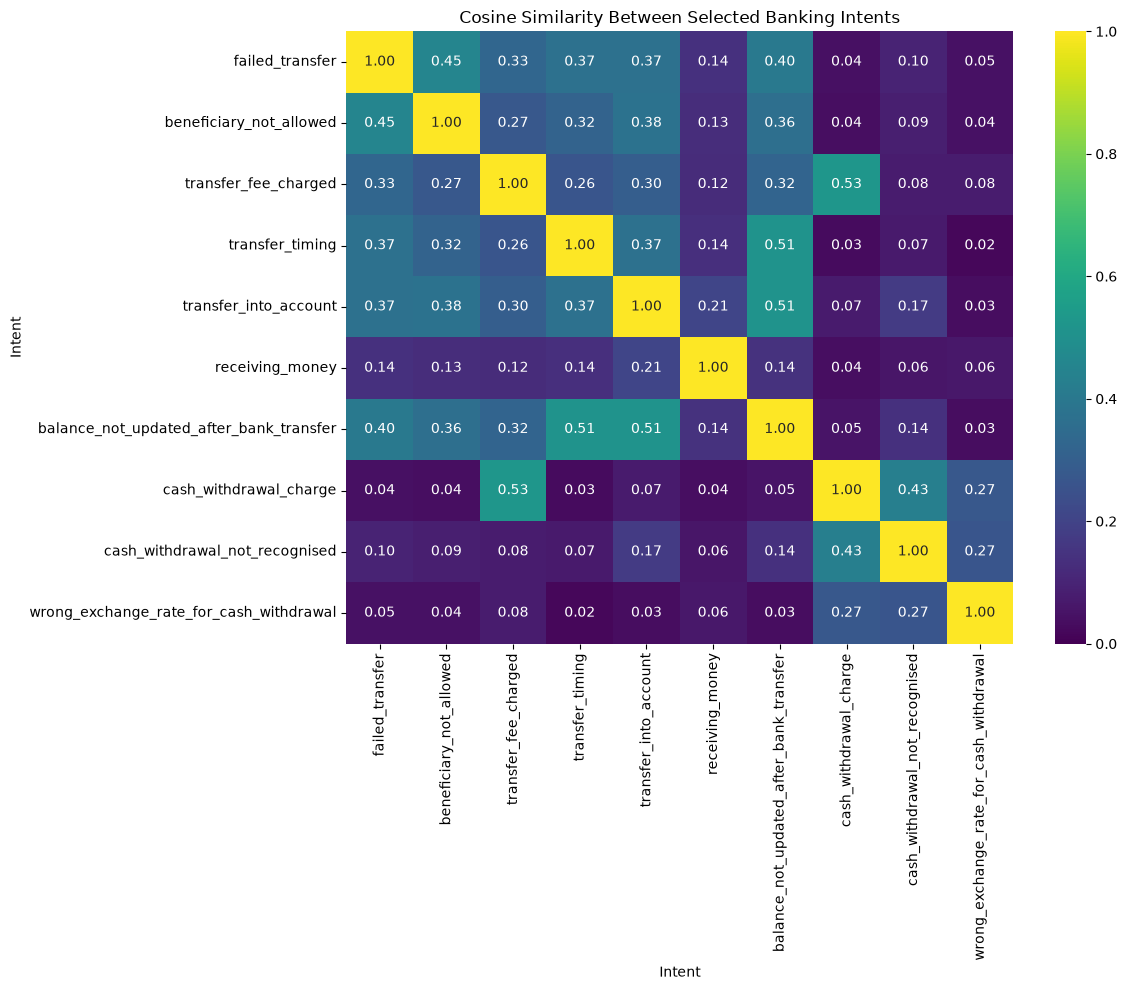

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    selected_similarity,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    vmin=0,
    vmax=1
)

plt.title('Cosine Similarity Between Selected Banking Intents')
plt.xlabel('Intent')
plt.ylabel('Intent')
plt.tight_layout()
plt.show()

In [45]:
similar_pairs = []

for i in range(len(intent_names)):
    for j in range(i + 1, len(intent_names)):
        similar_pairs.append({
            'intent_1': intent_names[i],
            'intent_2': intent_names[j],
            'similarity': similarity_matrix[i, j]
        })

similar_pairs_df = (
    pd.DataFrame(similar_pairs)
    .sort_values('similarity', ascending=False)
    .reset_index(drop=True)
)

similar_pairs_df.head(20)

,intent_1,intent_2,similarity
0,verify_my_identity,why_verify_identity,0.831521
1,card_payment_wrong_exchange_rate,wrong_exchange_rate_for_cash_withdrawal,0.804840
2,getting_virtual_card,virtual_card_not_working,0.795884
3,disposable_card_limits,get_disposable_virtual_card,0.705396
4,get_disposable_virtual_card,virtual_card_not_working,0.689449
5,unable_to_verify_identity,verify_my_identity,0.663384
6,get_physical_card,pin_blocked,0.643054
7,Refund_not_showing_up,request_refund,0.633730
8,unable_to_verify_identity,why_verify_identity,0.630735
9,card_payment_wrong_exchange_rate,exchange_rate,0.622392


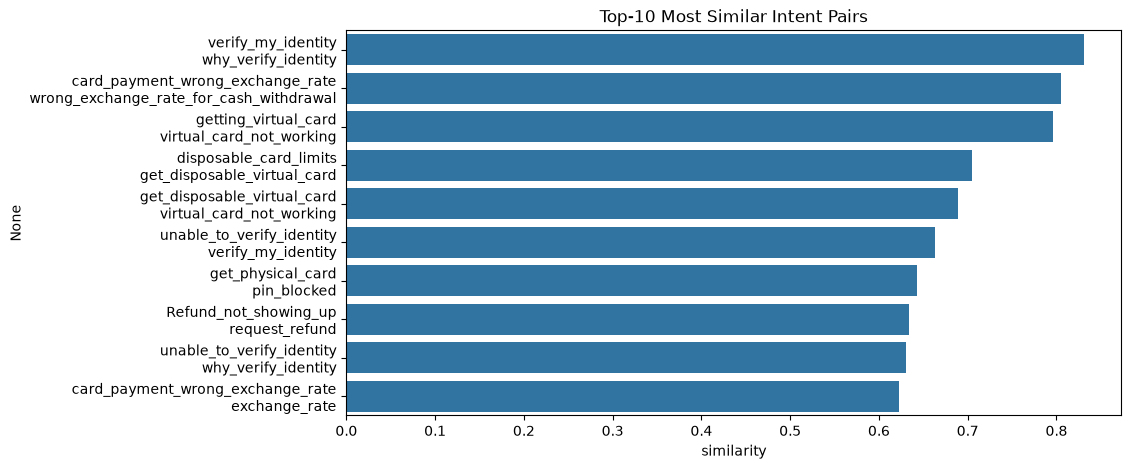

In [46]:
top10 = similar_pairs_df.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x='similarity',
    y=top10['intent_1'] + '\n' + top10['intent_2']
)

plt.title('Top-10 Most Similar Intent Pairs')

plt.show()

Cosine Similarity підтверджує що схожі intent будуть мати схожий словник. Найбільша подібність спостерігалася між intent verification, virtual card, transfer-related, exchange-rate-related. Ці результати свідчать про те, що помилки класифікації, ймовірно, виникають переважно між концептуально подібними категоріями, а не непов`язаними банківськими темами.